# <span style='color: darkblue'>Classifying Heart Disease</span>

## <span style='color: blue'>Introduction</span>

The purpose of this project is to apply Logistic Regression Modelling in Python to the [Heart Disease Dataset](https://archive.ics.uci.edu/dataset/45/heart+disease) from the UCI Machine Learning Repository.

The dataset was created from data recorded by the Cleveland Clinic Foundation that recorded information on various patient characteristics to try to classify the presence of heart disease in an individual.

The dataset contains the following information (refer to the link above for more information):
* `age`: age in years
* `sex`: sex (1 = male, 0 = female)
* `cp`: chest pain type
    + 1 = typical angina
    + 2 = atypical angina
    + 3 = non-anginal pain
    + 4 = asymptomatic
* `trestbps`: resting blood pressure in mm Hg
* `chol`: serum cholestoral in mg/dl
* `fbs`: fasting blood sugar > 120mg/dl (1 = yes, 0 = no)
* `restecg`: resting electrocardiographic results
    + 0 = normal
    + 1 = having ST-T wave abnormality
    + 2 = showing probable or definite left ventricular hypertrophy
* `thalach`: maximum heart rate achieved
* `exang`: exercise induced angina
* `oldpeak`: ST depression induced by exercise relative to rest
* `slope`: the slope of the peak exercise ST segment
    + 1 = upsloping
    + 2 = flat
    + 3 = downsloping
* `ca`: number of major vessels (0-3) coloured by flourosopy
* `thal`: 3 = normal; 6 = fixed defect; 7 = reversable defect
* `present`: diagnosis of heart disease

*<span style='color: green'>Import packages and data...</span>*

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

In [2]:
heart = pd.read_csv('heart_disease.csv', index_col=0)

## <span style='color: blue'>Exploring the Dataset</span>

In [3]:
heart.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,present
1,63,1,1,145,233,1,2,150,0,2.3,3,0.0,6.0,0
2,67,1,4,160,286,0,2,108,1,1.5,2,3.0,3.0,1
3,67,1,4,120,229,0,2,129,1,2.6,2,2.0,7.0,1
4,37,1,3,130,250,0,0,187,0,3.5,3,0.0,3.0,0
5,41,0,2,130,204,0,2,172,0,1.4,1,0.0,3.0,0


In [4]:
heart.info()

<class 'pandas.core.frame.DataFrame'>
Index: 303 entries, 1 to 303
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    object 
 12  thal      303 non-null    object 
 13  present   303 non-null    int64  
dtypes: float64(1), int64(11), object(2)
memory usage: 35.5+ KB


There are 303 observations in the dataset in 14 columns, including the target variable.</br>
Most of the columns are numeric apart from `ca` and `thal`, which should be numeric from the dictionary.</br>
Several of the columns are in fact categorical, even though they are represented numerically.

In [5]:
heart['ca'].value_counts()

ca
0.0    176
1.0     65
2.0     38
3.0     20
?        4
Name: count, dtype: int64

In [6]:
heart['thal'].value_counts()

thal
3.0    166
7.0    117
6.0     18
?        2
Name: count, dtype: int64

In [7]:
heart[(heart['ca'] == '?') | (heart['thal'] == '?')]

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,present
88,53,0,3,128,216,0,2,115,0,0.0,1,0.0,?,0
167,52,1,3,138,223,0,0,169,0,0.0,1,?,3.0,0
193,43,1,4,132,247,1,2,143,1,0.1,2,?,7.0,1
267,52,1,4,128,204,1,0,156,1,1.0,2,0.0,?,1
288,58,1,2,125,220,0,0,144,0,0.4,2,?,7.0,0
303,38,1,3,138,175,0,0,173,0,0.0,1,?,3.0,0


As there is a small number of records in both 'object' columns with a value of '?' (<2%), they shall be deleted from the dataset.

In [8]:
heart.drop(heart[(heart['ca'] == '?') | (heart['thal'] == '?')].index, inplace=True)
heart['ca'] = heart['ca'].astype('float64').astype('int64')
heart['thal'] = heart['thal'].astype('float64').astype('int64')

*<span style='color: green'>Investigate relationships...</span>*

In [9]:
numericals = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categoricals = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

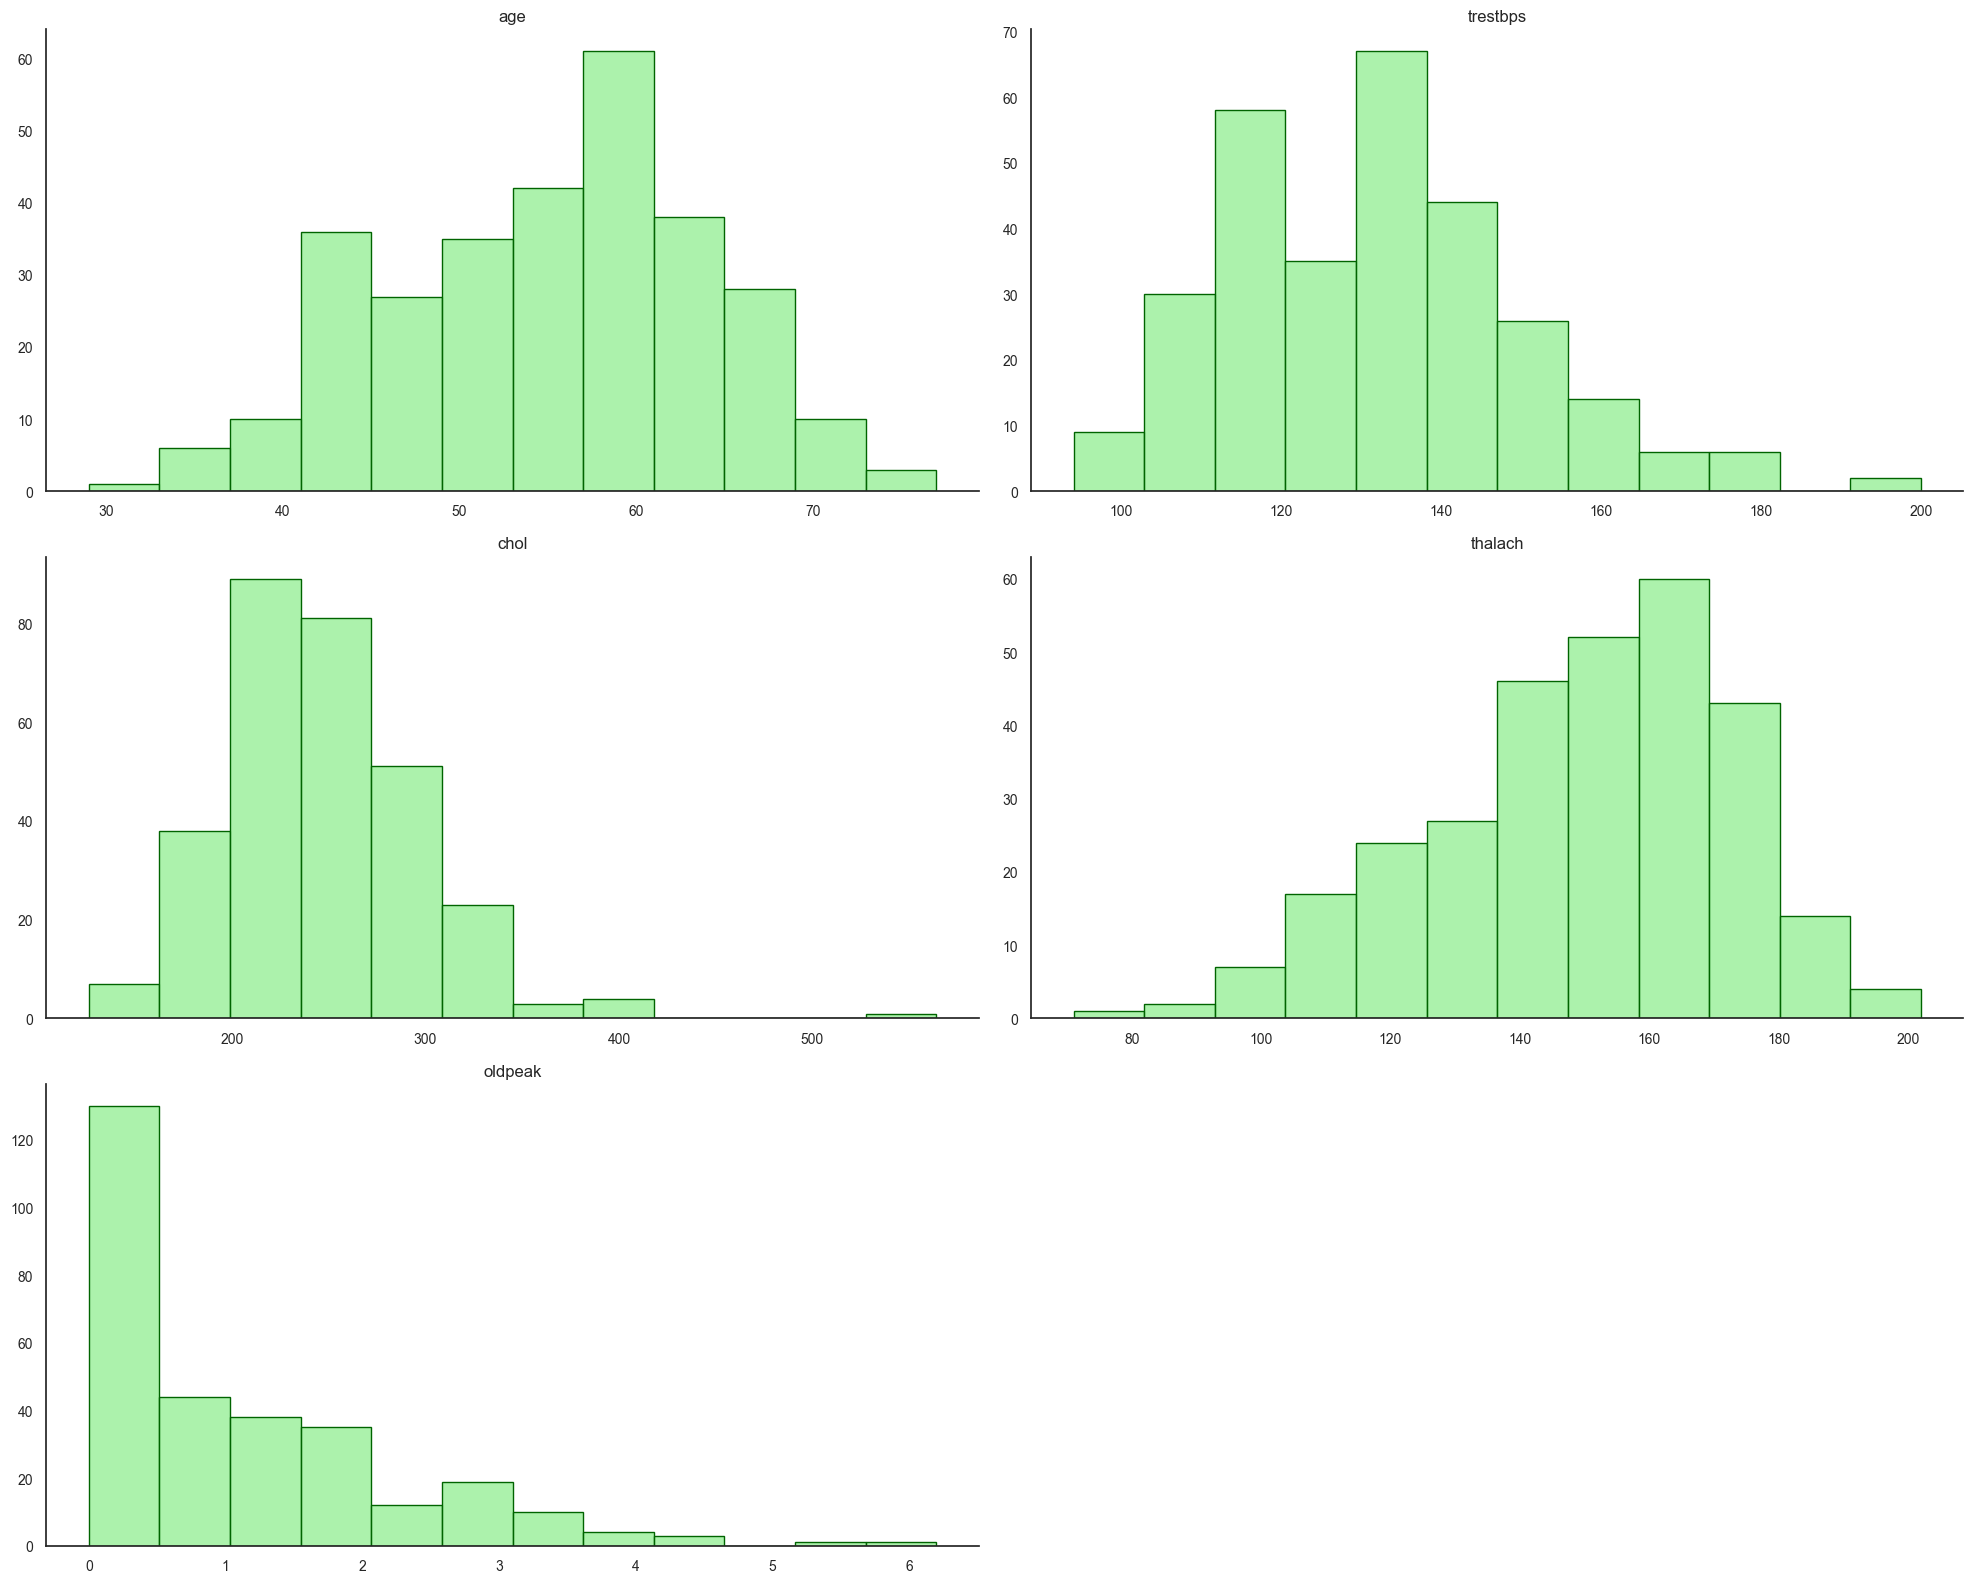

In [10]:
sns.set_theme(style='white')
fig, axes = plt.subplots(3, 2, figsize=(20, 16))
axes = axes.flatten()
for i, column in enumerate(numericals):
    sns.histplot(data=heart,
                 x=column,
                 ax=axes[i],
                 bins=12,
                 kde=False,
                 color='lightgreen',
                 edgecolor='darkgreen')
    axes[i].set_title(column, fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(left=False,
                        bottom=False,
                        labelsize=10)
    sns.despine(ax=axes[i])
plt.tight_layout()
fig.delaxes(axes[5])
plt.show()

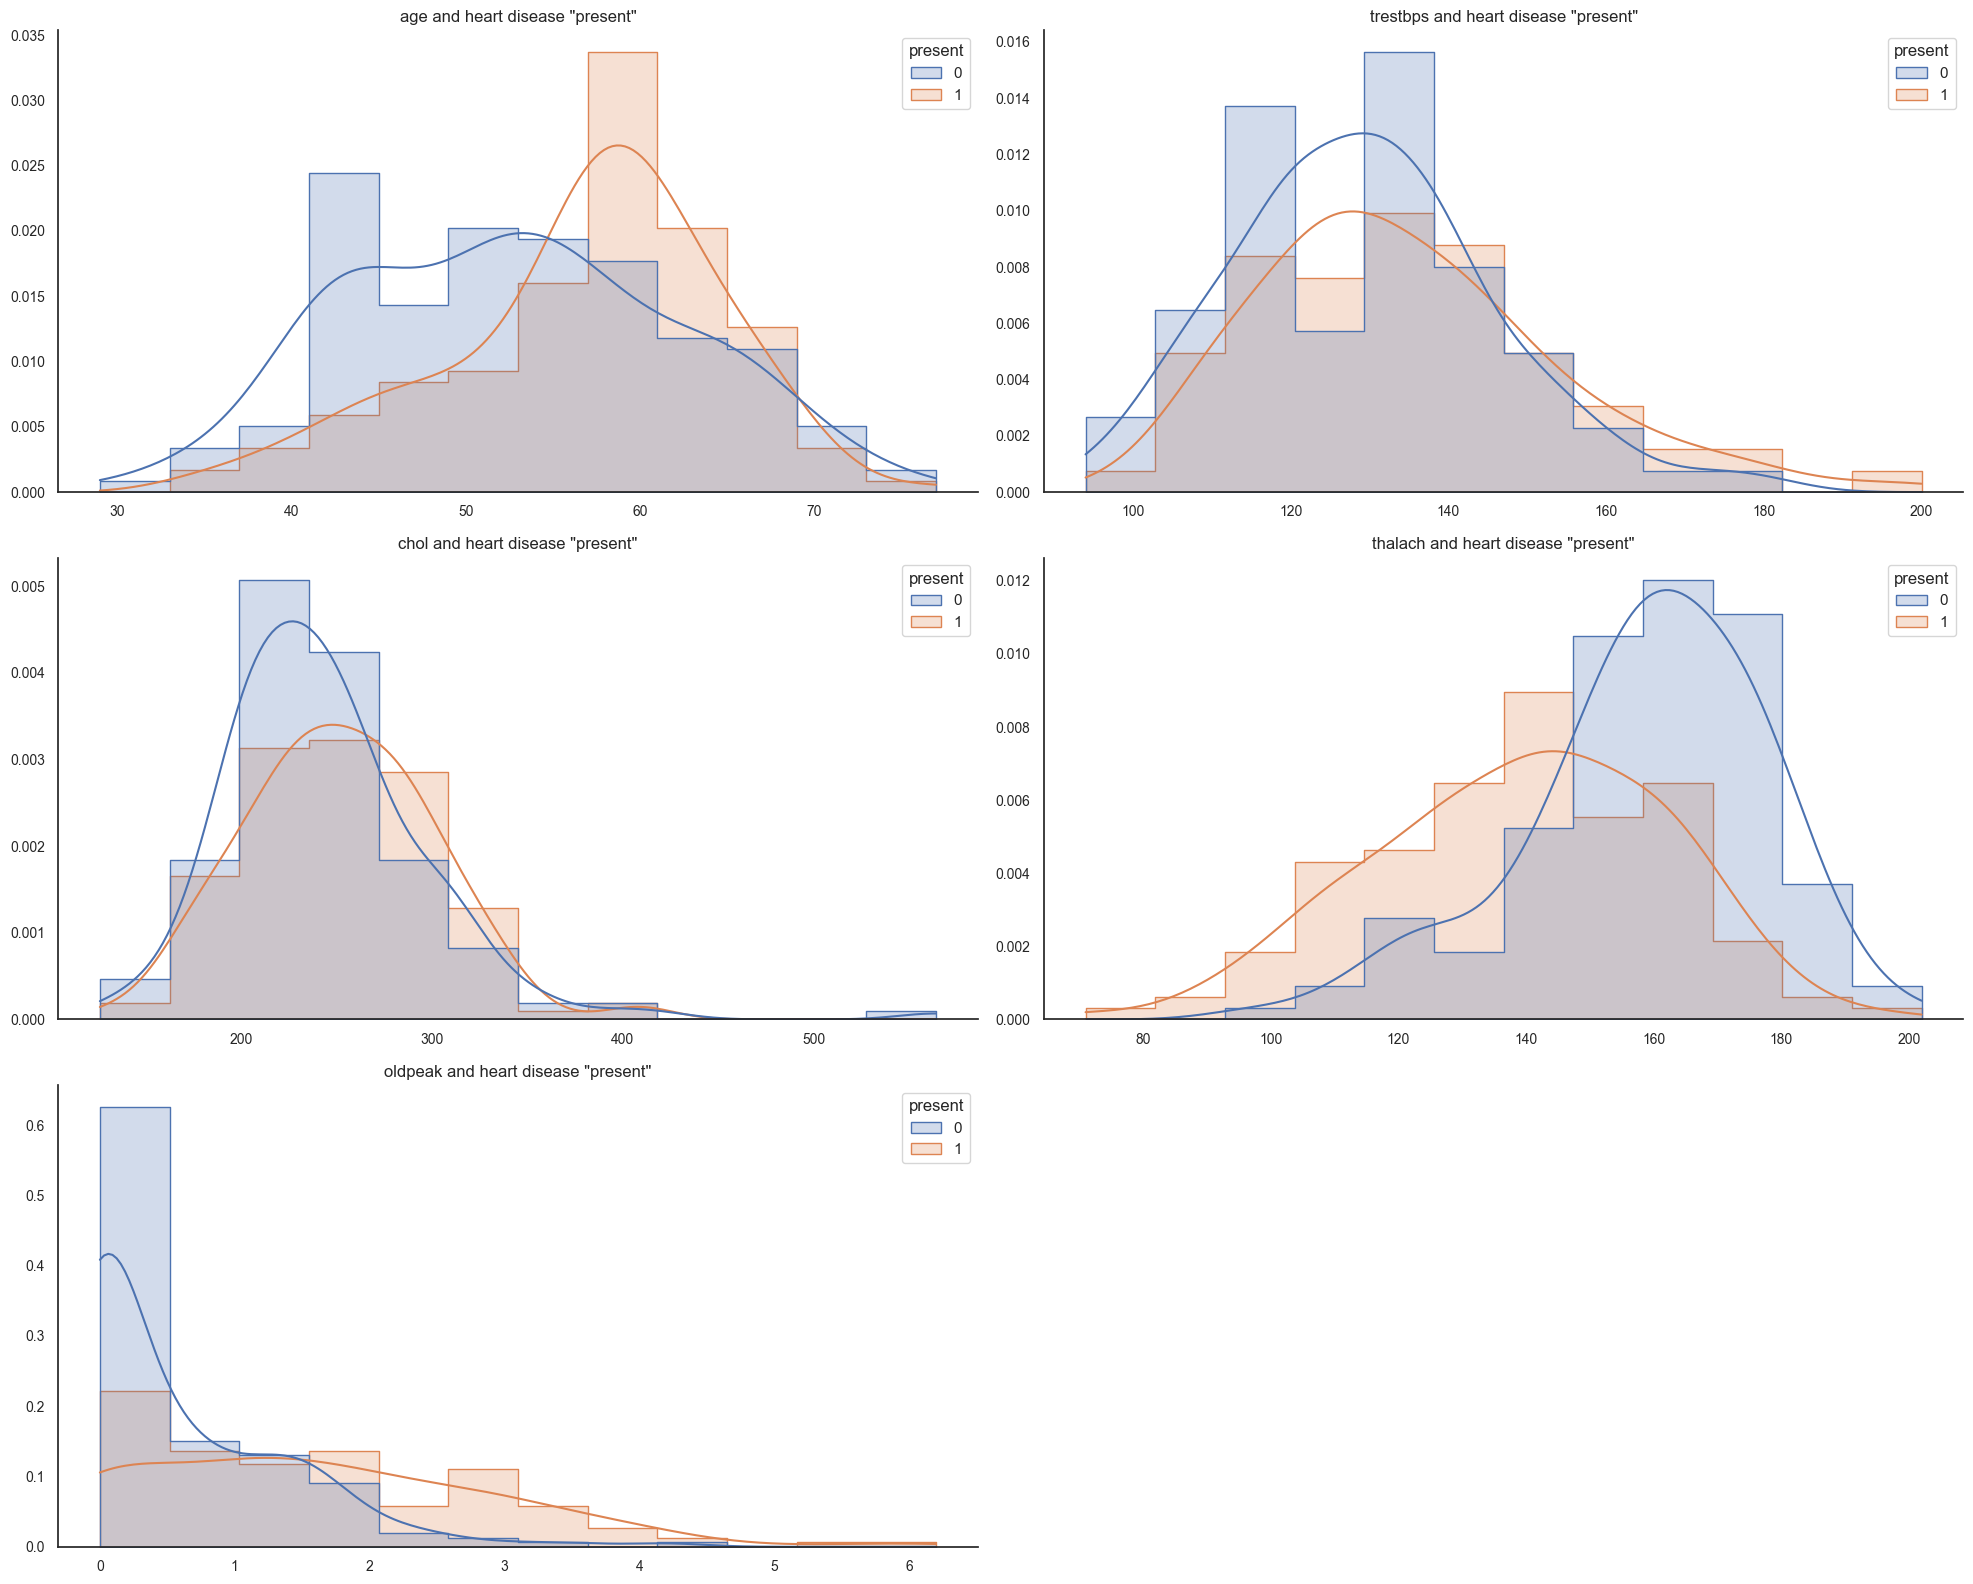

In [11]:
fig, axes = plt.subplots(3, 2, figsize=(20, 16))
axes = axes.flatten()
for i, column in enumerate(numericals):
    sns.histplot(data=heart,
                 x=column,
                 ax=axes[i],
                 hue='present',
                 bins=12,
                 kde=True,
                 element='step',
                 stat='density')
    axes[i].set_title(f'{column} and heart disease "present"', fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(left=False,
                        bottom=False,
                        labelsize=10)
    sns.despine(ax=axes[i])
plt.tight_layout()
fig.delaxes(axes[5])
plt.show()

Most of the numerical distributions are skewed to some extent and there are some differences in the distributions when stratified by whether heart disease is present or not, particularly `age` and `thalach`.

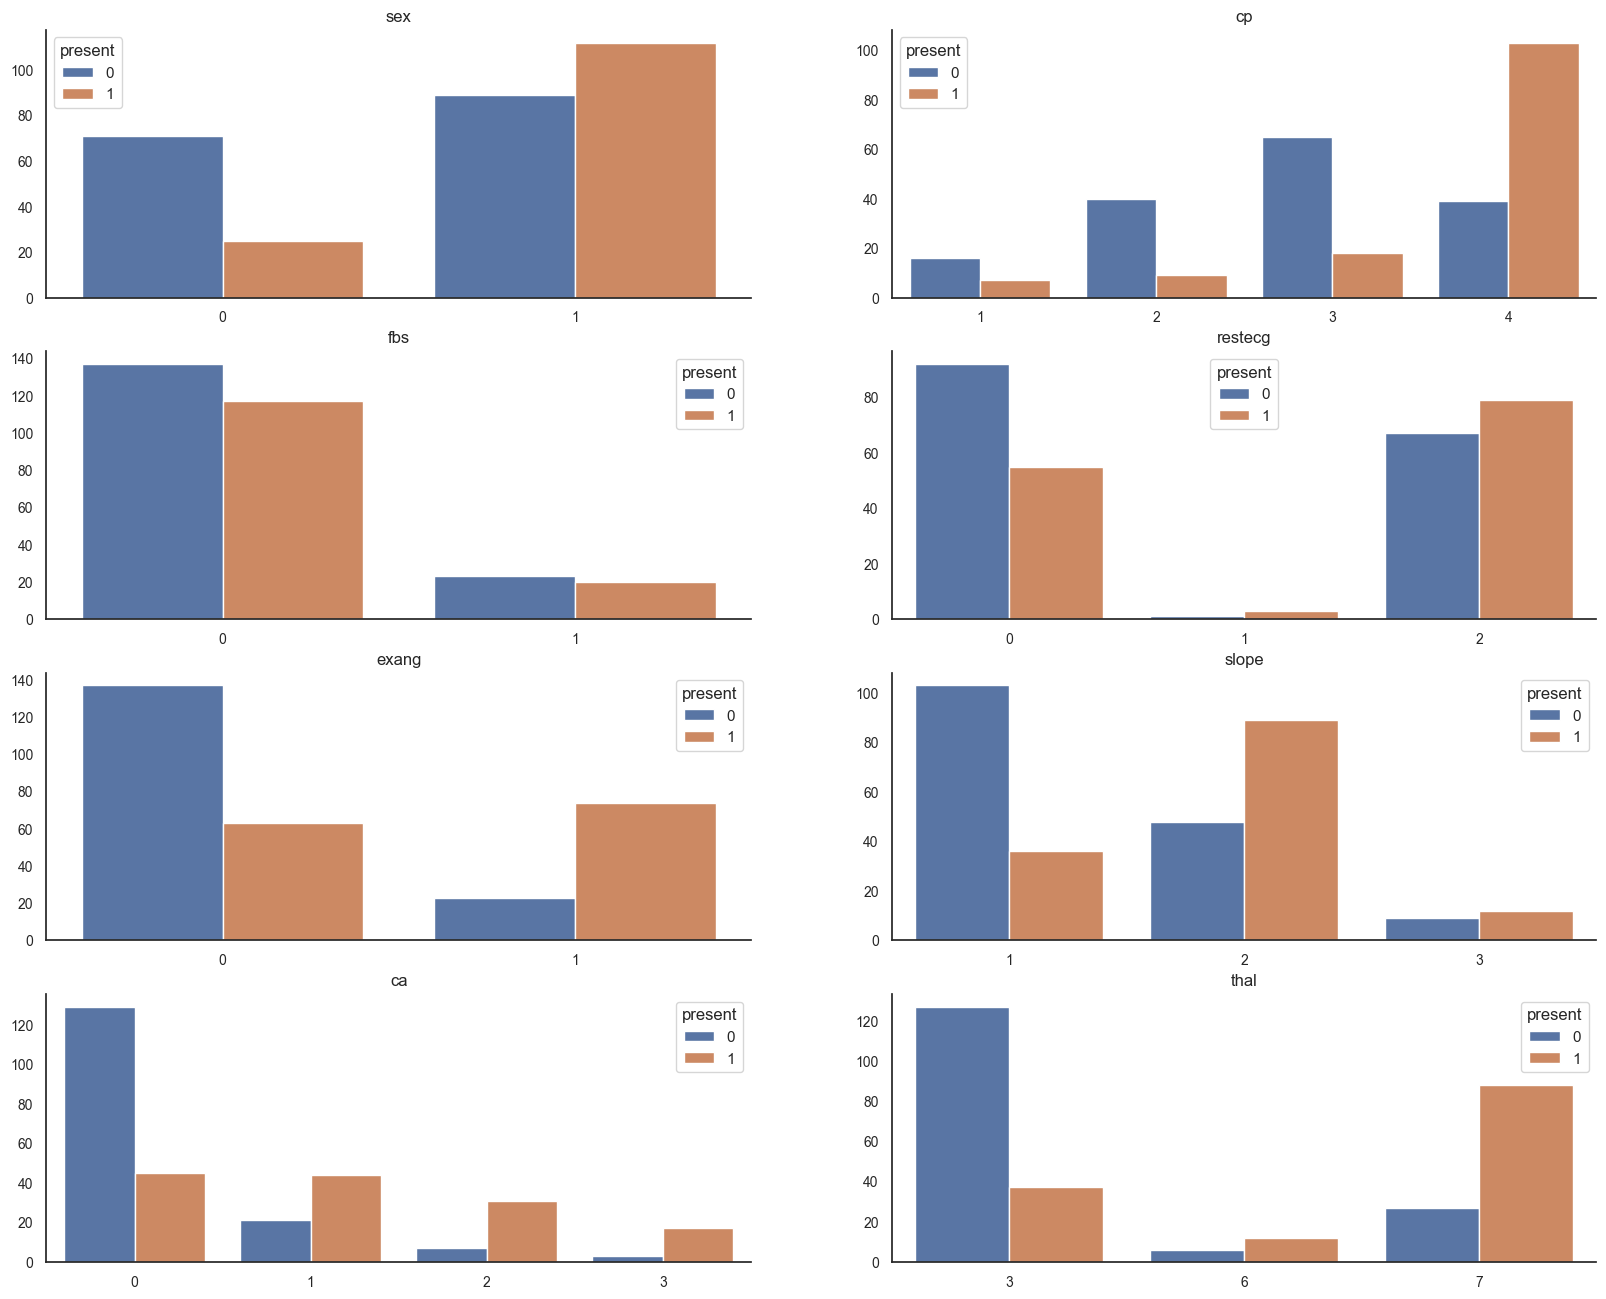

In [12]:
fig, axes = plt.subplots(4, 2, figsize=(20, 16))
axes = axes.flatten()
for i, column in enumerate(categoricals):
    sns.countplot(data=heart,
                 x=column,
                 ax=axes[i],
                 hue='present')
    axes[i].set_title(column, fontsize=12)
    axes[i].set_xlabel('')
    axes[i].set_ylabel('')
    axes[i].tick_params(left=False,
                        bottom=False,
                        labelsize=10)
    sns.despine(ax=axes[i])
# plt.tight_layout()
plt.show()

It appears that most of the categorical columns, except for `fbs` and perhaps `restecg` will be useful in the model.

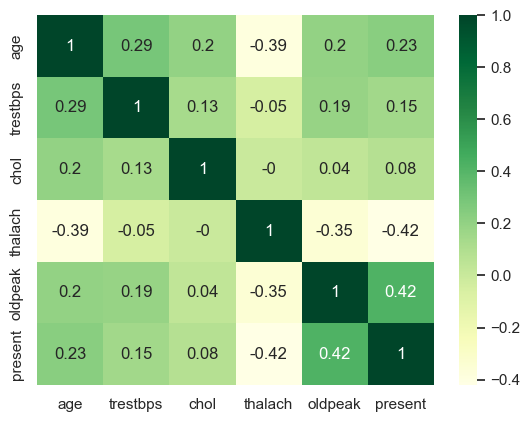

In [13]:
numericals.append('present')
correlations = round(heart[numericals].corr(), 2)
sns.heatmap(correlations, annot=True, cmap='YlGn')
plt.show()

In [14]:
correlations[['present']].sort_values(by='present', key=lambda x: abs(x), ascending=False).iloc[1:]

,present
thalach,-0.42
oldpeak,0.42
age,0.23
trestbps,0.15
chol,0.08


Based on the above analysis, the following predictors shall be used in the model:

**Numerical Columns:**
* `age`
* `thalach` (although left skewed, leave as is initially)
* `oldpeak` (log transform due to right skew)

**Categorical Columns:**
* `sex`
* `cp` (one-hot encode due to no inherent order)
* `exang`
* `slope`
* `ca`
* `thal`

Domain knowledge is insufficient to decide whether some of the categorical columns are ordered or not so, where relevant and unless stated otherwise, order is assumed.

*<span style='color: green'>Transform columns on a copy of the DataFrame...</span>*

In [15]:
heart[['thalach', 'oldpeak']].describe()

,thalach,oldpeak
count,297.000000,297.000000
mean,149.599327,1.055556
std,22.941562,1.166123
min,71.000000,0.000000
25%,133.000000,0.000000
50%,153.000000,0.800000
75%,166.000000,1.600000
max,202.000000,6.200000


In [16]:
heart_tm = heart[['age', 'thalach', 'oldpeak', 'sex', 'exang', 'slope', 'ca', 'thal']].copy()
cp_ohe = pd.get_dummies(heart['cp'].astype(str), drop_first=True, prefix='cp').astype(int)
heart_tm = pd.concat([heart_tm, cp_ohe], axis=1)
heart_tm['oldpeak'] = np.log(heart_tm['oldpeak'] + 0.01) # Handles min of zero
heart_tm.head()

,age,thalach,oldpeak,sex,exang,slope,ca,thal,cp_2,cp_3,cp_4
1,63,150,0.837248,1,0,3,0,6,0,0,0
2,67,108,0.412110,1,1,2,3,3,0,0,1
3,67,129,0.959350,1,1,2,2,7,0,0,1
4,37,187,1.255616,1,0,3,0,3,0,1,0
5,41,172,0.343590,0,0,1,0,3,1,0,0


## <span style='color: blue'>Dividing the Data</span>

*<span style='color: green'>Split dataset into training and testing...</span>*

In [17]:
X_train, X_test, y_train, y_test = train_test_split(heart_tm,
                                                    heart['present'],
                                                    test_size=0.2,
                                                    random_state=6)

In [18]:
y_train.value_counts(normalize=True)

present
0    0.523207
1    0.476793
Name: proportion, dtype: float64

In [19]:
y_test.value_counts(normalize=True)

present
0    0.6
1    0.4
Name: proportion, dtype: float64

Both states of `present` are represented in both the training and test datasets.

## <span style='color: blue'>Building the Model</span>

*<span style='color: green'>Create and assess model on training dataset...</span>*

In [20]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [21]:
y_train_pred = model.predict(X_train)

In [22]:
accuracy_train = accuracy_score(y_train, y_train_pred)
print(f'The Accuracy Score of the model on the training dataset is {accuracy_train:.2f}')

The Accuracy Score of the model on the training dataset is 0.85


In [23]:
tn, fp, fn, tp = confusion_matrix(y_train, y_train_pred).ravel()
sensitivity_train = tp / (tp + fn)
specificity_train = tn / (tn + fp)
print(f'Sensitivity (True Positive Rate) of the model on the training dataset is {sensitivity_train:.3f}')
print(f'Specificity (True Negative Rate) of the model on the training dataset is {specificity_train:.3f}')

Sensitivity (True Positive Rate) of the model on the training dataset is 0.814
Specificity (True Negative Rate) of the model on the training dataset is 0.887


These metrics show that the model performs well on the training dataset but are optimistic metrics.

## <span style='color: blue'>Interpreting the Model Coefficients</span>

In [24]:
features = list(X_train.columns)
model_log_odds = model.coef_.flatten()
model_odds_ratios = np.exp(model_log_odds)
coefs = pd.DataFrame({
    'Feature': features,
    'Log_Odds': model_log_odds,
    'Odds': model_odds_ratios}).sort_values(by='Odds', ascending=False)
coefs

,Feature,Log_Odds,Odds
10,cp_4,1.037551,2.822297
6,ca,1.028955,2.798140
3,sex,0.810262,2.248497
5,slope,0.781702,2.185188
4,exang,0.698200,2.010131
7,thal,0.369887,1.447571
8,cp_2,0.337897,1.401996
2,oldpeak,0.066115,1.068349
0,age,0.004255,1.004264
1,thalach,-0.013361,0.986728


The coefficients of the model suggest that `cp_4` (aysymptomatic chest pain), `ca`, `sex`, `slope` and `exang` have the biggest effect on increasing the chance of heart disease being present.</br>
The presence of `cp_3` (non-anginal chest pain) gives the biggest decrease in the odds of heart disease being present.</br>
`age` and `thalach` have the lowest impact.</br>
The result of `age` not having much of an impact is perhaps surprising.

# <span style='color: blue'>Final Model Evaluation</span>

*<span style='color: green'>Assess model on the test dataset...</span>*

In [25]:
y_test_pred = model.predict(X_test)

In [26]:
accuracy_test = accuracy_score(y_test, y_test_pred)
print(f'The Accuracy Score of the model on the test dataset is {accuracy_test:.2f}')

The Accuracy Score of the model on the test dataset is 0.88


In [27]:
tn, fp, fn, tp = confusion_matrix(y_test, y_test_pred).ravel()
sensitivity_test = tp / (tp + fn)
specificity_test = tn / (tn + fp)
print(f'The Sensitivity of the model on the test dataset is {sensitivity_test:.3f}')
print(f'The Specificity of the model on the test dataset is {specificity_test:.3f}')

The Sensitivity of the model on the test dataset is 0.792
The Specificity of the model on the test dataset is 0.944


The accuracy of the the model on the test data is an improvement on the training data, mainly due to the fact that the specificity is increased. This shows a really good true negative classification but the true positive rate is slightly lower on the test data.

## <span style='color: blue'>Conclusions</span>

Whilst the model performs pretty well, in this context, the lower sensitivity would mean that cases of heart disease would get missed more than is perhaps acceptable. It identifies cases of not having heart disease well with a low risk of misdiagnosis.</br>
It seems counterintuitive that age does not have as much an impact as expected and scaling the features may impact this.</br>
The model should be refined to try to increase the sensitivity for a clinical setting.